<a href="https://colab.research.google.com/github/csa180915-design/jump-model-verification/blob/main/jump_model_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computational Verification of "A unified model for the long and high jump"

This notebook reproduces the main numerical results of O. Helene and M. T. Yamashita's paper, "A unified model for the long and high jump," American Journal of Physics 73, 906-908 (2005).

The calculation verifies the long jump and high jump models using energy conservation, projectile motion, and conservation of angular momentum.

## Main Goals

1. Reproduce the additional energy estimate of 550 J.
2. Reproduce the long jump calculation from the paper.
3. Reproduce the high jump calculation from the paper.
4. Plot the relationship between additional energy and long jump distance.
5. Plot the relationship between body inclination angle and high jump height.

Additional Energy Estimate
--------------------------
Additional energy estimate: 550.0 J

Long Jump Results
-----------------
Vertical velocity vy: 3.708 m/s
Flight time: 0.757 s
Flight distance L2: 7.568 m
Total jump distance: 8.368 m
Takeoff angle: 20.35 degrees

High Jump Results at theta = 56 degrees
---------------------------------------
Speed perpendicular to bar v: 4.663 m/s
Horizontal velocity vh: 3.866 m/s
Initial vertical velocity vv: 2.608 m/s
Final vertical velocity vv': 4.533 m/s
Center of mass rise: 1.048 m
Total height using h0 = 1.1 m: 2.148 m
Total height using bar model: 1.878 m
Takeoff angle: 49.54 degrees


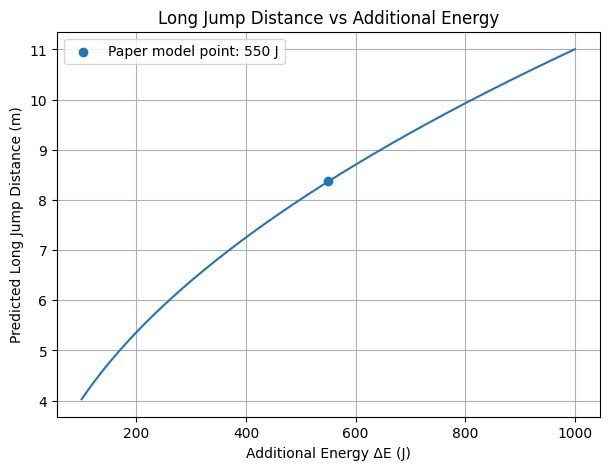

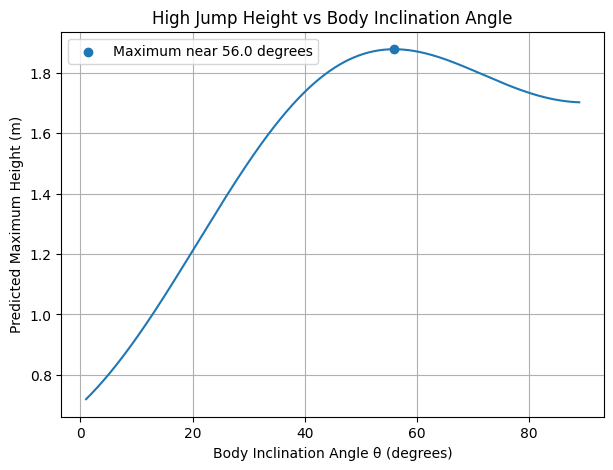


High Jump Angle Sweep
---------------------
Best theta: 56.02 degrees
Maximum height: 1.878 m

Summary Table
-------------


,Quantity,Python Result,Paper Value
0,Additional energy,550 J,550 J
1,Long jump vertical velocity,3.71 m/s,about 3.7 m/s
2,Long jump flight distance L2,7.57 m,about 7.6 m
3,Total long jump distance,8.37 m,about 8.4 m
4,Long jump takeoff angle,20.3 degrees,about 20 degrees
5,High jump theta,56 degrees,56 degrees
6,High jump final vertical velocity,4.53 m/s,about 4.5 m/s
7,High jump center of mass rise,1.05 m,about 1.0 m
8,High jump total height using h0 = 1.1 m,2.15 m,about 2.1 m
9,High jump takeoff angle,49.5 degrees,about 49-50 degrees



Saved files
-----------
long_jump_energy_vs_distance.png
high_jump_angle_vs_height.png
jump_model_results.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Computational Verification of
# "A unified model for the long and high jump"
# O. Helene and M. T. Yamashita, American Journal of Physics, 2005
# ============================================================

# ------------------------------------------------------------
# Basic constants
# ------------------------------------------------------------

m = 80.0          # mass of athlete (kg)
g = 9.8           # gravitational acceleration (m/s^2)
dE = 550.0        # additional energy during takeoff (J)


# ------------------------------------------------------------
# 1. Additional Energy Estimate
# ------------------------------------------------------------

F_leg = 3000.0    # force produced by one leg (N)
weight = 800.0    # approximate weight of 80 kg athlete using g = 10 m/s^2 (N)
dy = 0.25         # rise of center of mass during final stride (m)

added_energy_estimate = (F_leg - weight) * dy

print("Additional Energy Estimate")
print("--------------------------")
print("Additional energy estimate:", round(added_energy_estimate, 3), "J")


# ------------------------------------------------------------
# 2. Long Jump Calculation
# ------------------------------------------------------------

v0_long = 10.0    # horizontal running speed for long jump (m/s)
L1 = 0.4          # takeoff distance contribution (m)
L3 = 0.4          # landing distance contribution (m)

# Vertical velocity gained from additional energy
vy_long = np.sqrt(2 * dE / m)

# Flight time, assuming same takeoff and landing height of center of mass
T_long = 2 * vy_long / g

# Flight distance
L2 = v0_long * T_long

# Total long jump distance
L_total = L1 + L2 + L3

# Takeoff angle
angle_long = np.degrees(np.arctan(vy_long / v0_long))

print("\nLong Jump Results")
print("-----------------")
print("Vertical velocity vy:", round(vy_long, 3), "m/s")
print("Flight time:", round(T_long, 3), "s")
print("Flight distance L2:", round(L2, 3), "m")
print("Total jump distance:", round(L_total, 3), "m")
print("Takeoff angle:", round(angle_long, 2), "degrees")


# ------------------------------------------------------------
# 3. High Jump Calculation
# ------------------------------------------------------------

v0_high = 7.5      # horizontal running speed for high jump (m/s)
ell = 1.0          # half length of bar model (m)
theta_deg = 56.0   # body inclination angle used in the paper
theta = np.radians(theta_deg)

# Velocity components from conservation of angular momentum
v = (3/4) * v0_high * np.sin(theta)
vh = (3/4) * v0_high * np.sin(theta)**2
vv = (3/4) * v0_high * np.sin(theta) * np.cos(theta)

# Final vertical velocity after adding 550 J
vv_prime = np.sqrt(vv**2 + 2 * dE / m)

# Rise of center of mass
height_rise = vv_prime**2 / (2 * g)

# Total height using initial center of mass height about 1.1 m
h0 = 1.1
h_total_com = h0 + height_rise

# Total height using simplified bar model
h_total_bar = ell * np.sin(theta) + height_rise

# Takeoff angle after adding energy
angle_high = np.degrees(np.arctan(vv_prime / vh))

print("\nHigh Jump Results at theta = 56 degrees")
print("---------------------------------------")
print("Speed perpendicular to bar v:", round(v, 3), "m/s")
print("Horizontal velocity vh:", round(vh, 3), "m/s")
print("Initial vertical velocity vv:", round(vv, 3), "m/s")
print("Final vertical velocity vv':", round(vv_prime, 3), "m/s")
print("Center of mass rise:", round(height_rise, 3), "m")
print("Total height using h0 = 1.1 m:", round(h_total_com, 3), "m")
print("Total height using bar model:", round(h_total_bar, 3), "m")
print("Takeoff angle:", round(angle_high, 2), "degrees")


# ------------------------------------------------------------
# 4. Graph 1: Additional Energy vs Long Jump Distance
# ------------------------------------------------------------

energy_values = np.linspace(100, 1000, 300)

vy_values = np.sqrt(2 * energy_values / m)
T_values = 2 * vy_values / g
L2_values = v0_long * T_values
L_total_values = L1 + L2_values + L3

plt.figure(figsize=(7, 5))
plt.plot(energy_values, L_total_values)
plt.scatter([dE], [L_total], label="Paper model point: 550 J")
plt.xlabel("Additional Energy ΔE (J)")
plt.ylabel("Predicted Long Jump Distance (m)")
plt.title("Long Jump Distance vs Additional Energy")
plt.grid(True)
plt.legend()
plt.savefig("long_jump_energy_vs_distance.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 5. Graph 2: Body Inclination Angle vs High Jump Height
# ------------------------------------------------------------

theta_values_deg = np.linspace(1, 89, 500)
theta_values = np.radians(theta_values_deg)

vh_values = (3/4) * v0_high * np.sin(theta_values)**2
vv_values = (3/4) * v0_high * np.sin(theta_values) * np.cos(theta_values)
vv_prime_values = np.sqrt(vv_values**2 + 2 * dE / m)

height_rise_values = vv_prime_values**2 / (2 * g)
h_bar_values = ell * np.sin(theta_values) + height_rise_values

max_index = np.argmax(h_bar_values)
best_theta = theta_values_deg[max_index]
best_height = h_bar_values[max_index]

plt.figure(figsize=(7, 5))
plt.plot(theta_values_deg, h_bar_values)
plt.scatter([best_theta], [best_height], label=f"Maximum near {best_theta:.1f} degrees")
plt.xlabel("Body Inclination Angle θ (degrees)")
plt.ylabel("Predicted Maximum Height (m)")
plt.title("High Jump Height vs Body Inclination Angle")
plt.grid(True)
plt.legend()
plt.savefig("high_jump_angle_vs_height.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nHigh Jump Angle Sweep")
print("---------------------")
print("Best theta:", round(best_theta, 2), "degrees")
print("Maximum height:", round(best_height, 3), "m")


# ------------------------------------------------------------
# 6. Summary Table
# ------------------------------------------------------------

results = {
    "Quantity": [
        "Additional energy",
        "Long jump vertical velocity",
        "Long jump flight distance L2",
        "Total long jump distance",
        "Long jump takeoff angle",
        "High jump theta",
        "High jump final vertical velocity",
        "High jump center of mass rise",
        "High jump total height using h0 = 1.1 m",
        "High jump takeoff angle"
    ],
    "Python Result": [
        f"{dE:.0f} J",
        f"{vy_long:.2f} m/s",
        f"{L2:.2f} m",
        f"{L_total:.2f} m",
        f"{angle_long:.1f} degrees",
        f"{theta_deg:.0f} degrees",
        f"{vv_prime:.2f} m/s",
        f"{height_rise:.2f} m",
        f"{h_total_com:.2f} m",
        f"{angle_high:.1f} degrees"
    ],
    "Paper Value": [
        "550 J",
        "about 3.7 m/s",
        "about 7.6 m",
        "about 8.4 m",
        "about 20 degrees",
        "56 degrees",
        "about 4.5 m/s",
        "about 1.0 m",
        "about 2.1 m",
        "about 49-50 degrees"
    ]
}

df = pd.DataFrame(results)

print("\nSummary Table")
print("-------------")
display(df)

# Save the results as a CSV file
df.to_csv("jump_model_results.csv", index=False)

print("\nSaved files")
print("-----------")
print("long_jump_energy_vs_distance.png")
print("high_jump_angle_vs_height.png")
print("jump_model_results.csv")